# Cross-Hospital Generalization of Heart-Disease Classifiers

> **Educational research notebook — not a diagnostic device.** The models below are evaluated on a
> historical benchmark and must not be used for clinical decisions.

**Abstract—** A model can perform well under internal validation yet fail when moved to a hospital
with different patients, measurements, and missing-data patterns. This notebook compares logistic
regression, random forests, and a small neural network on four UCI heart-disease cohorts. We first
estimate internal performance on Cleveland using stratified five-fold cross-validation. We then
perform directed source-to-target hospital transfer using the nine variables that are actually
observed across all sites. Preprocessing is fitted inside each training fold or on the source
hospital only. The study emphasizes discrimination (ROC-AUC), transfer gaps, and limitations caused
by small, imbalanced cohorts. Its purpose is to teach sound external-validation reasoning, not to
claim clinical readiness.

**Index Terms—** clinical machine learning, dataset shift, external validation, heart disease,
ROC-AUC, reproducibility.

### Research questions

1. How accurately do the three model families discriminate disease within Cleveland?
2. How much performance changes when the training and test hospitals differ?
3. Does model complexity improve internal fit at the cost of transportability?

### Learning outcomes

By the end, you should be able to identify disguised missing values, keep preprocessing inside the
training boundary, distinguish internal from external validation, interpret a transfer matrix, and
state conclusions at the strength supported by the data.

### Study map

| stage | data boundary | purpose |
|---|---|---|
| Part I | Cleveland, five held-out folds | model development and internal validation |
| Part II | one source hospital → one different target hospital | external transport test |
| Synthesis | model-level macro averages across directed transfers | compare robustness, with caveats |

## How to read the evidence

This notebook separates four kinds of statement:

| label | meaning in this notebook |
|---|---|
| **Definition** | terminology or an equation; no empirical claim is being made |
| **Observation** | a pattern in the displayed sample or figure |
| **Result** | a quantity produced by the stated evaluation protocol |
| **Interpretation** | a plausible explanation that remains open to alternative causes |

The independent evaluation unit is **a patient within an internal fold, and a target hospital in the transfer analysis**, and the principal endpoint is **ROC-AUC; accuracy and F1 are supporting endpoints**.
Comparisons are meaningful only when models use the same split, features, and endpoint. Decimal places
are shown for reproducibility, not as a claim of equivalent precision.

# Part 1 — The Project: Building the Classifier

## Step 0 — Setting up our tools

A *library* is a pre-written bundle of code someone else built so we don't have to. We bring our tools in **a
few at a time** and explain what each is for.

**The basics: numbers, tables, and pictures**
- `numpy` — fast math on big lists of numbers (*arrays*).
- `pandas` — **tables** of data, like a spreadsheet in Python (*DataFrames*).
- `matplotlib` — draws **charts** so we can *see* our data.

In [1]:
import numpy as np                 # fast math on arrays
import pandas as pd                # spreadsheet-style tables (DataFrames)
import matplotlib.pyplot as plt    # charts

**scikit-learn — classic machine-learning toolbox**
- `LogisticRegression`, `RandomForestClassifier` — two of our three models.
- `SimpleImputer` — fills in missing values; `StandardScaler` — puts features on the same scale.
- `StratifiedKFold`, `GridSearchCV` — cross-validation and light tuning, done fairly.
- `accuracy_score`, `roc_auc_score`, `f1_score` — measure how good our predictions are.

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

**scikit-learn neural network.** The third model is a small multi-layer perceptron (MLP). Keeping all
three models in scikit-learn makes the notebook lighter, faster, and reproducible on an ordinary CPU.

In [3]:
from sklearn.neural_network import MLPClassifier

**Last bits** — a display helper, warning control, and folders for exported results.

In [4]:
import os, warnings
warnings.filterwarnings("ignore")
from IPython.display import display
print("All libraries imported successfully.")

All libraries imported successfully.


### Making our results repeatable (random seeds)

Machine learning uses **randomness** (shuffling, a model's starting values). To get the **same result every
time**, we fix a *random seed* — a starting number for the random-number generator. We use `42`.

In [5]:
import random
SEED=42
random.seed(SEED); np.random.seed(SEED)
SITE_COLORS={"Cleveland":"#2c6fbb","Hungary":"#3a7d44","Switzerland":"#c0392b","VA":"#e0a13a"}
plt.rcParams.update({"figure.facecolor":"white","axes.grid":True,"grid.alpha":0.3,
                     "axes.spines.top":False,"axes.spines.right":False,
                     "font.size":11,"axes.titlesize":12,"axes.titleweight":"bold"})
for d in ["outputs/figures","outputs/results"]: os.makedirs(d, exist_ok=True)
print("Seed set to 42 — results will be repeatable.")

Seed set to 42 — results will be repeatable.


## Step 1 — Getting the data

Each hospital's data is a plain table with **14 columns** describing a patient (age, sex, chest-pain type, blood
pressure, cholesterol, …) and uses `?` for a value that wasn't recorded. The last column, `num`, is the
diagnosis. We try the official download and, if it's unavailable here, load verified local copies of the same
files.

In [6]:
COLS=["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
      "exang","oldpeak","slope","ca","thal","num"]
SITE_FILES={"Cleveland":"processed.cleveland.data","Hungary":"processed.hungarian.data",
            "Switzerland":"processed.switzerland.data","VA":"processed.va.data"}
UCI_BASE="https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/"
# plain-English meaning of each column (handy reference)
MEANING={"age":"age","sex":"sex (1=M,0=F)","cp":"chest-pain type","trestbps":"resting blood pressure",
         "chol":"cholesterol","fbs":"fasting blood sugar>120","restecg":"resting ECG","thalach":"max heart rate",
         "exang":"exercise-induced angina","oldpeak":"ST depression","slope":"ST slope","ca":"# major vessels",
         "thal":"thalassemia test","num":"diagnosis (0-4)"}

In [7]:
def load_all():
    try:
        import requests, io
        def _get(f):
            r=requests.get(UCI_BASE+f,timeout=20); r.raise_for_status()
            return pd.read_csv(io.StringIO(r.text),header=None,names=COLS,na_values="?")
        return {s:_get(f) for s,f in SITE_FILES.items()},"live download"
    except Exception as e:
        print(f"(Live download not available here: {type(e).__name__} — using local copies.)")
        return {s:pd.read_csv("mirror/"+f,header=None,names=COLS,na_values="?")
                for s,f in SITE_FILES.items()},"verified local copies"

raw,DATA_SOURCE=load_all(); sites=list(SITE_FILES)
data={}
for s in sites:
    df=raw[s].copy()
    for c in COLS: df[c]=pd.to_numeric(df[c],errors="coerce")   # make sure everything is numeric
    df["site"]=s; df["target"]=(df["num"]>0).astype(int)        # 1 = has heart disease
    data[s]=df
print("Data source:", DATA_SOURCE)
for s in sites: print(f"  {s:11s}: {len(data[s])} patients")

Data source: live download
  Cleveland  : 303 patients
  Hungary    : 294 patients
  Switzerland: 123 patients
  VA         : 200 patients


Let's peek at the first few **Cleveland** patients — this is the hospital we build our model on.

In [8]:
display(data["Cleveland"].head().style.set_caption("First 5 Cleveland patients (raw)"))

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,site,target
0,63.000000,1.000000,1.000000,145.000000,233.000000,1.000000,2.000000,150.000000,0.000000,2.300000,3.000000,0.000000,6.000000,0,Cleveland,0
1,67.000000,1.000000,4.000000,160.000000,286.000000,0.000000,2.000000,108.000000,1.000000,1.500000,2.000000,3.000000,3.000000,2,Cleveland,1
2,67.000000,1.000000,4.000000,120.000000,229.000000,0.000000,2.000000,129.000000,1.000000,2.600000,2.000000,2.000000,7.000000,1,Cleveland,1
3,37.000000,1.000000,3.000000,130.000000,250.000000,0.000000,0.000000,187.000000,0.000000,3.500000,3.000000,0.000000,3.000000,0,Cleveland,0
4,41.000000,0.000000,2.000000,130.000000,204.000000,0.000000,2.000000,172.000000,0.000000,1.400000,1.000000,0.000000,3.000000,0,Cleveland,0


## Step 2 — Looking at the data

### 2a. A sneaky problem: impossible numbers

A person's **cholesterol or blood pressure can never be 0** — so any `0` here is really a *disguised* missing
value. We find them and turn them into proper blanks (so we don't feed the model fake numbers).

In [9]:
zeros=pd.DataFrame({"chol == 0":[int((data[s]["chol"]==0).sum()) for s in sites],
                    "trestbps == 0":[int((data[s]["trestbps"]==0).sum()) for s in sites]},index=sites)
display(zeros.style.set_caption("Impossible zeros (really 'missing')").background_gradient(cmap="Oranges",axis=None))
for s in sites:
    data[s].loc[data[s]["chol"]==0,"chol"]=np.nan
    data[s].loc[data[s]["trestbps"]==0,"trestbps"]=np.nan
print("Fixed. (Switzerland records cholesterol as 0 for ALL its patients — a famous quirk.)")

,chol == 0,trestbps == 0
Cleveland,0,0
Hungary,0,0
Switzerland,123,0
VA,49,1


Fixed. (Switzerland records cholesterol as 0 for ALL its patients — a famous quirk.)


### 2b. Is the Cleveland data balanced?

About 46% of Cleveland patients have heart disease — nicely balanced, so plain accuracy is a fair score here.

Cleveland: 46% have heart disease, 54% don't


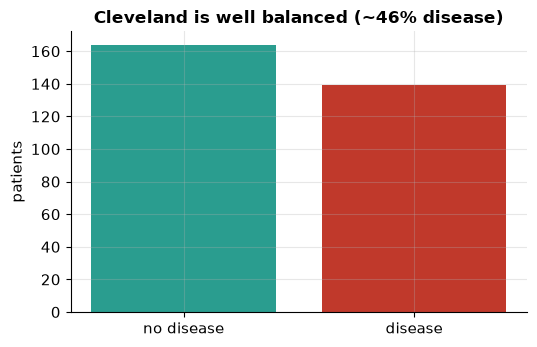

In [10]:
clev=data["Cleveland"]
print(f"Cleveland: {clev['target'].mean()*100:.0f}% have heart disease, {(1-clev['target'].mean())*100:.0f}% don't")
fig,ax=plt.subplots(figsize=(5.5,3.6))
ax.bar(["no disease","disease"],[ (clev['target']==0).sum(),(clev['target']==1).sum() ],color=["#2a9d8f","#c0392b"])
ax.set_ylabel("patients"); ax.set_title("Cleveland is well balanced (~46% disease)")
plt.tight_layout(); plt.savefig("outputs/figures/class_balance.png",dpi=150); plt.show()

### 2c. Which measurements separate sick from healthy?

Box plots split a measurement by outcome. Where the two boxes barely overlap, that feature is a strong clue.
Notice **max heart rate (`thalach`)** is *lower* in patients with disease, while **`oldpeak`** and **`ca`** are
*higher* — these turn out to be the model's best signals.

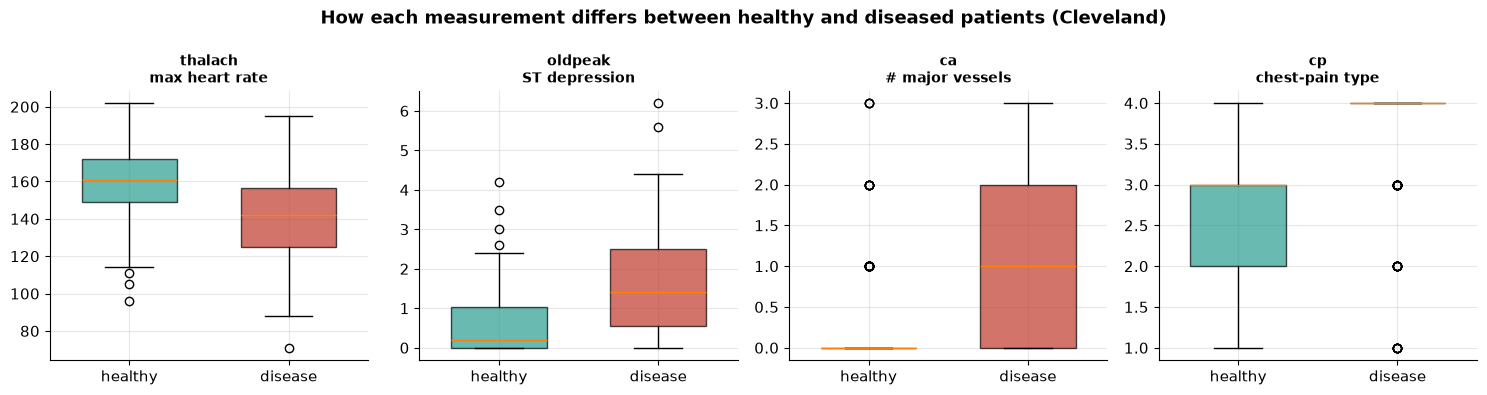

In [11]:
feats=["thalach","oldpeak","ca","cp"]
fig,axes=plt.subplots(1,4,figsize=(15,4))
for ax,f in zip(axes,feats):
    g=[clev.loc[clev["target"]==0,f].dropna(),clev.loc[clev["target"]==1,f].dropna()]
    bp=ax.boxplot(g,tick_labels=["healthy","disease"],patch_artist=True,widths=0.6)
    for p,c in zip(bp["boxes"],["#2a9d8f","#c0392b"]): p.set_facecolor(c); p.set_alpha(0.7)
    ax.set_title(f"{f}\n{MEANING[f]}",fontsize=10)
fig.suptitle("How each measurement differs between healthy and diseased patients (Cleveland)",fontweight="bold")
plt.tight_layout(); plt.savefig("outputs/figures/feature_vs_target.png",dpi=150); plt.show()

### 🧪 Your turn
1. Is `age` higher for patients with disease? By how much? (hint: `clev.groupby("target")["age"].mean()`)
2. Make a box plot of `chol` (cholesterol) by outcome — is it as clear a signal as `thalach`?
3. What fraction of Cleveland's `ca` and `thal` values are missing? (we'll need to fill those in Step 3)

In [12]:
# === edit me! ===
print("Mean age by outcome:\n", clev.groupby("target")["age"].mean().round(1).to_string())
# TODO: your experiments here.

Mean age by outcome:
 target
0    52.6
1    56.6


## Step 3 — Preparing the data

For Part 1 we want the **best possible model on Cleveland**, so we use **all 13 measurements** — including
`ca`, `thal`, and `slope`, which are among the strongest predictors. Cleveland records them for almost every
patient (only a handful are blank), so we simply **fill the few blanks** with the median and **rescale** every
feature. Both steps are *learned from the training data only* so we never peek at the test patients.

In [13]:
FEATURES_FULL=["age","sex","cp","trestbps","chol","fbs","restecg","thalach",
               "exang","oldpeak","slope","ca","thal"]   # all 13 predictors
print("Cleveland uses all", len(FEATURES_FULL), "measurements.")
print("Missing in Cleveland:", {f:int(clev[f].isna().sum()) for f in FEATURES_FULL if clev[f].isna().sum()>0})

Cleveland uses all 13 measurements.
Missing in Cleveland: {'ca': 4, 'thal': 2}


## Step 4 — Building the models

Three models, simplest to most flexible. Each in its own small cell.

**Model 1 — Logistic Regression.** A straight-line-style classifier; we lightly tune its `C` (caution dial) with
cross-validation. Simple and, on small clean medical data, very hard to beat.

In [14]:
def make_logreg():
    return GridSearchCV(LogisticRegression(max_iter=3000,class_weight="balanced",random_state=SEED),
                        {"C":[0.05,0.1,0.3,1.0]},cv=5,scoring="roc_auc",n_jobs=-1)

**Model 2 — Random Forest.** A committee of 400 decision trees that vote; captures curvier patterns than a line.

In [15]:
def make_rf():
    return RandomForestClassifier(n_estimators=400,min_samples_leaf=3,class_weight="balanced",
                                  random_state=SEED,n_jobs=-1)

**Model 3 — a small neural network (MLP).** Two hidden layers learn nonlinear combinations of the
measurements. L2 regularization and early stopping reduce overfitting. This remains a compact
benchmark model, not a clinical deep-learning system.

In [16]:
def build_mlp(n):
    return MLPClassifier(hidden_layer_sizes=(32,16), activation="relu", alpha=0.01,
                         learning_rate_init=1e-3, max_iter=600, early_stopping=True,
                         validation_fraction=0.2, n_iter_no_change=20, random_state=SEED)

def fit_mlp(Xtr,ytr):
    return build_mlp(Xtr.shape[1]).fit(Xtr,ytr)
print("Three models ready.")

Three models ready.


## Step 5 — Training & testing with cross-validation

With only 303 patients, a single train/test split is luck-of-the-draw. So we use **5-fold cross-validation**:
split Cleveland into 5 parts, and 5 times train on 4 parts and test on the held-out part. Every patient gets a
prediction from a model that **never saw them** — the fairest possible test. We clean (fill blanks + rescale)
*inside each fold* so there's no leakage.

In [17]:
Xfull=clev[FEATURES_FULL]; y=clev["target"].values
skf=StratifiedKFold(5,shuffle=True,random_state=SEED)
oof={m:np.zeros(len(y)) for m in ["LogReg","RandomForest","MLP"]}   # out-of-fold probabilities

for tr,te in skf.split(Xfull,y):
    med=Xfull.iloc[tr].median()
    imp_tr=Xfull.iloc[tr].fillna(med); imp_te=Xfull.iloc[te].fillna(med)
    sc=StandardScaler().fit(imp_tr); Xtr,Xte=sc.transform(imp_tr),sc.transform(imp_te)
    lr=make_logreg().fit(Xtr,y[tr]);  oof["LogReg"][te]=lr.predict_proba(Xte)[:,1]
    rf=make_rf().fit(Xtr,y[tr]);      oof["RandomForest"][te]=rf.predict_proba(Xte)[:,1]
    mm=fit_mlp(Xtr,y[tr]);            oof["MLP"][te]=mm.predict_proba(Xte)[:,1]
print("5-fold cross-validation done — every Cleveland patient now has an honest prediction.")

5-fold cross-validation done — every Cleveland patient now has an honest prediction.


## Step 6 — Measuring it

We grade each model with **accuracy** (% correct), **ROC-AUC** (how well it ranks sick above healthy — 0.5 is a
coin flip, 1.0 perfect), and **F1** (balances precision and recall).

In [18]:
rows=[]
for m,p in oof.items():
    pred=(p>=0.5).astype(int)
    rows.append([m,accuracy_score(y,pred),roc_auc_score(y,p),f1_score(y,pred)])
within=pd.DataFrame(rows,columns=["model","accuracy","ROC_AUC","F1"])
within.round(4).to_csv("outputs/results/within_cleveland.csv",index=False)
display(within.style.set_caption("Cleveland model — 5-fold cross-validated performance")
        .format({"accuracy":"{:.3f}","ROC_AUC":"{:.3f}","F1":"{:.3f}"})
        .background_gradient(subset=["accuracy","ROC_AUC"],cmap="Greens").hide(axis="index"))
best=within.loc[within["ROC_AUC"].idxmax()]
print(f"Best model: {best['model']} — accuracy {best['accuracy']:.3f}, ROC-AUC {best['ROC_AUC']:.3f}  →  a genuinely good heart-disease classifier. ✅")

model,accuracy,ROC_AUC,F1
LogReg,0.838,0.907,0.821
RandomForest,0.842,0.910,0.821
MLP,0.779,0.883,0.745


Best model: RandomForest — accuracy 0.842, ROC-AUC 0.910  →  a genuinely good heart-disease classifier. ✅


# Part 2 — Discussion: Does it survive a new hospital?

The Cleveland analysis estimates **internal** discrimination. It does not answer the deployment
question: what happens when the case mix, measurement process, and missingness pattern change?

The travel test therefore uses only the **nine measurements with genuine coverage across all four
hospitals**. In particular, Switzerland records cholesterol as zero for every patient, so
cholesterol is not treated as a portable feature. This is a stricter but more defensible comparison
than filling an entirely absent source variable with information pooled from other hospitals.

In [19]:
FEATURES_SHARED=["age","sex","cp","trestbps","fbs","restecg","thalach","exang","oldpeak"]
print("Portable measurements used for the travel test:", len(FEATURES_SHARED))

def fit_preprocessor(train_df):
    """Fit imputation and scaling on the training rows only."""
    med = train_df[FEATURES_SHARED].median()
    if med.isna().any():
        missing = med.index[med.isna()].tolist()
        raise ValueError(f"Training source has no observations for: {missing}")
    filled = train_df[FEATURES_SHARED].fillna(med)
    scaler = StandardScaler().fit(filled)
    def transform(df):
        return scaler.transform(df[FEATURES_SHARED].fillna(med))
    return transform

Portable measurements used for the travel test: 9


### Taking each model to every other hospital

For every off-diagonal source→target pair, preprocessing and model fitting use the source hospital
only; the target hospital is untouched until scoring. On the diagonal, preprocessing is re-fitted
inside every cross-validation fold. This distinction prevents test-fold statistics from leaking
into the model. Because target hospitals vary greatly in size and prevalence, each directed pair is
shown rather than hidden behind one pooled score.

In [20]:
import time
def safe_auc(yy,p): return roc_auc_score(yy,p) if len(np.unique(yy))>1 else np.nan
def fit_lr(X,yv): return LogisticRegression(C=1.0,max_iter=2000,class_weight="balanced",random_state=SEED).fit(X,yv)
def fit_rf2(X,yv): return RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=SEED,n_jobs=-1).fit(X,yv)
def fit_mlp2(X,yv):
    return build_mlp(X.shape[1]).fit(X,yv)

models=["LogReg","RandomForest","MLP"]; AUC={m:np.full((4,4),np.nan) for m in models}; records=[]
t0=time.time()
for i,tr in enumerate(sites):
    source=data[tr]
    source_prep=fit_preprocessor(source)
    Xtr,ytr=source_prep(source),source["target"].values
    lr,rf,mm=fit_lr(Xtr,ytr),fit_rf2(Xtr,ytr),fit_mlp2(Xtr,ytr)
    for j,te in enumerate(sites):
        if i==j:
            skf2=StratifiedKFold(5,shuffle=True,random_state=SEED)
            oof_site={m:np.full(len(source),np.nan) for m in models}
            for a,b in skf2.split(source,ytr):
                fold_prep=fit_preprocessor(source.iloc[a])
                Xa,Xb=fold_prep(source.iloc[a]),fold_prep(source.iloc[b])
                oof_site["LogReg"][b]=fit_lr(Xa,ytr[a]).predict_proba(Xb)[:,1]
                oof_site["RandomForest"][b]=fit_rf2(Xa,ytr[a]).predict_proba(Xb)[:,1]
                oof_site["MLP"][b]=fit_mlp2(Xa,ytr[a]).predict_proba(Xb)[:,1]
            for m in models: AUC[m][i,j]=safe_auc(ytr,oof_site[m])
            regime="same hospital"
        else:
            Xte,yte=source_prep(data[te]),data[te]["target"].values
            AUC["LogReg"][i,j]=safe_auc(yte,lr.predict_proba(Xte)[:,1])
            AUC["RandomForest"][i,j]=safe_auc(yte,rf.predict_proba(Xte)[:,1])
            AUC["MLP"][i,j]=safe_auc(yte,mm.predict_proba(Xte)[:,1])
            regime="new hospital"
        for m in models:
            records.append({"train_site":tr,"test_site":te,"model":m,
                            "regime":regime,"ROC_AUC":AUC[m][i,j]})
n_cross=sum(1 for r in records if r["regime"]=="new hospital")//len(models)
print(f"Tested every hospital pair in {time.time()-t0:.0f}s ({n_cross} new-hospital tests per model).")

Tested every hospital pair in 5s (12 new-hospital tests per model).


### A heatmap per model (the "report card")

Rows = the hospital we **trained** on; columns = the hospital we **tested** on. Boxed diagonal = same hospital. Greener = better; the fade off the diagonal is the real-world drop.

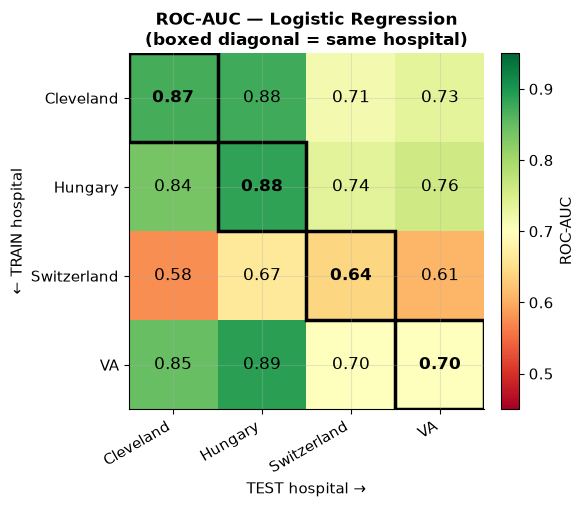

In [21]:
def heatmap(mat,name,fname):
    fig,ax=plt.subplots(figsize=(6,5.2)); im=ax.imshow(mat,cmap="RdYlGn",vmin=0.45,vmax=0.95)
    ax.set_xticks(range(4)); ax.set_yticks(range(4)); ax.set_xticklabels(sites,rotation=30,ha="right"); ax.set_yticklabels(sites)
    ax.set_xlabel("TEST hospital →"); ax.set_ylabel("← TRAIN hospital"); ax.set_title(f"ROC-AUC — {name}\n(boxed diagonal = same hospital)")
    for i in range(4):
        for j in range(4):
            v=mat[i,j]; ax.text(j,i,"—" if np.isnan(v) else f"{v:.2f}",ha="center",va="center",fontsize=12,fontweight="bold" if i==j else "normal")
            if i==j: ax.add_patch(plt.Rectangle((j-.5,i-.5),1,1,fill=False,edgecolor="black",lw=2.5))
    fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04,label="ROC-AUC"); plt.tight_layout(); plt.savefig(fname,dpi=150); plt.show()
heatmap(AUC["LogReg"],"Logistic Regression","outputs/figures/cross_hospital_heatmap_logreg.png")

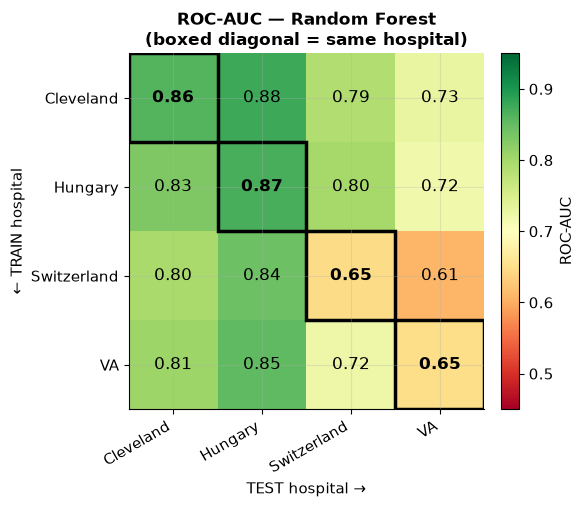

In [22]:
heatmap(AUC["RandomForest"],"Random Forest","outputs/figures/cross_hospital_heatmap_rf.png")

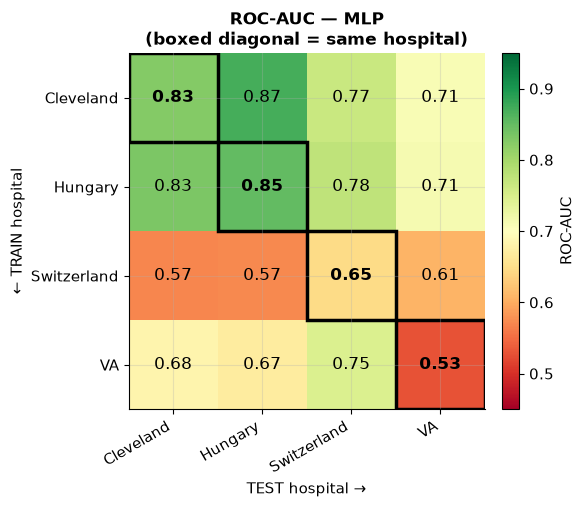

In [23]:
heatmap(AUC["MLP"],"MLP","outputs/figures/cross_hospital_heatmap_mlp.png")

### The "generalization gap" — how much each model loses

For each model we report the macro-average internal AUC and the macro-average over directed
new-hospital transfers. Their signed difference is **internal minus external AUC**: positive means
the external average is lower; negative means it is higher. This is a descriptive contrast, not a
pure robustness statistic, because the internal and external test sets differ in both hospital and
difficulty. Read it together with the full transfer matrix and the absolute external AUC.

model,same_hospital_AUC,new_hospital_AUC,gap
LogReg,0.774,0.745,+0.028
RandomForest,0.756,0.781,-0.025
MLP,0.713,0.709,+0.003


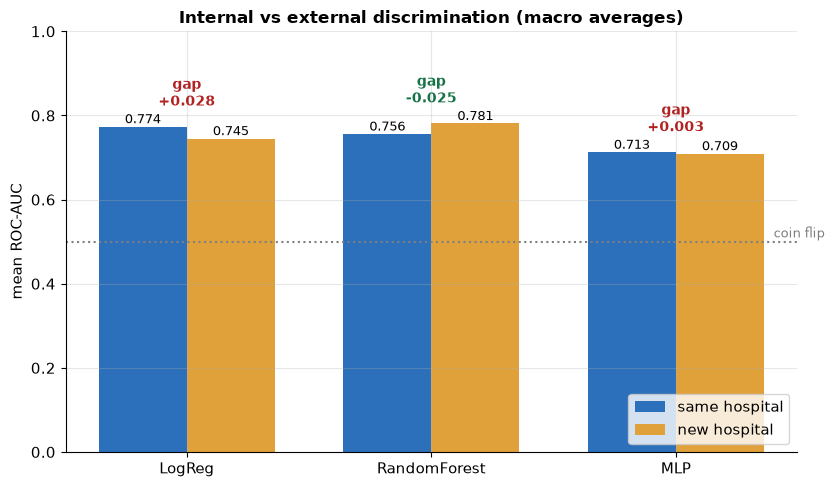

In [24]:
off=~np.eye(4,dtype=bool)
gap_df=pd.DataFrame([{"model":m,"same_hospital_AUC":np.nanmean(np.diag(AUC[m])),
                      "new_hospital_AUC":np.nanmean(AUC[m][off]),
                      "gap":np.nanmean(np.diag(AUC[m]))-np.nanmean(AUC[m][off])} for m in models])
gap_df.round(4).to_csv("outputs/results/generalization_gap.csv",index=False)
display(gap_df.style.set_caption("Generalization gap = same-hospital AUC − new-hospital AUC")
        .format({"same_hospital_AUC":"{:.3f}","new_hospital_AUC":"{:.3f}","gap":"{:+.3f}"})
        .background_gradient(subset=["gap"],cmap="Reds").hide(axis="index"))
x=np.arange(3); w=0.36
fig,ax=plt.subplots(figsize=(8.5,5))
b1=ax.bar(x-w/2,gap_df["same_hospital_AUC"],w,label="same hospital",color="#2c6fbb")
b2=ax.bar(x+w/2,gap_df["new_hospital_AUC"],w,label="new hospital",color="#e0a13a")
for bars in (b1,b2):
    for b in bars: ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.008,f"{b.get_height():.3f}",ha="center",fontsize=9)
for xi,r in zip(x,gap_df.itertuples()):
    ax.annotate(f"gap\n{r.gap:+.3f}",(xi,max(r.same_hospital_AUC,r.new_hospital_AUC)+0.05),ha="center",fontsize=10,fontweight="bold",color="#b22222" if r.gap>0 else "#177245")
ax.axhline(0.5,ls=":",c="grey"); ax.text(2.4,0.51,"coin flip",color="grey",fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(models); ax.set_ylim(0,1.0); ax.set_ylabel("mean ROC-AUC")
ax.set_title("Internal vs external discrimination (macro averages)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.savefig("outputs/figures/generalization_gap_summary.png",dpi=150); plt.show()

In [25]:
pairs=pd.DataFrame(records)
wide=pairs.pivot_table(index=["train_site","test_site","regime"],columns="model",values="ROC_AUC").reset_index()
wide=wide[["train_site","test_site","regime","LogReg","RandomForest","MLP"]]; wide.to_csv("outputs/results/pairwise_auc.csv",index=False)
display(wide.style.set_caption("Every train → test pair").format({"LogReg":"{:.3f}","RandomForest":"{:.3f}","MLP":"{:.3f}"},na_rep="—").hide(axis="index"))
print("Most robust to a new hospital (smallest gap):", gap_df.loc[gap_df["gap"].idxmin(),"model"])
print("Least robust (biggest gap):", gap_df.loc[gap_df["gap"].idxmax(),"model"])

train_site,test_site,regime,LogReg,RandomForest,MLP
Cleveland,Cleveland,same hospital,0.870,0.861,0.826
Cleveland,Hungary,new hospital,0.875,0.878,0.872
Cleveland,Switzerland,new hospital,0.714,0.789,0.765
Cleveland,VA,new hospital,0.734,0.728,0.709
Hungary,Cleveland,new hospital,0.836,0.830,0.832
Hungary,Hungary,same hospital,0.884,0.869,0.851
Hungary,Switzerland,new hospital,0.736,0.799,0.775
Hungary,VA,new hospital,0.760,0.718,0.713
Switzerland,Cleveland,new hospital,0.576,0.797,0.571
Switzerland,Hungary,new hospital,0.667,0.844,0.572


Most robust to a new hospital (smallest gap): RandomForest
Least robust (biggest gap): LogReg


## Validity checks and interpretation rules

- **No preprocessing leakage:** medians and scaling parameters are learned only from training rows.
- **No pseudo-shared cholesterol:** the all-zero Swiss field is excluded from the transport feature set.
- **Different estimands:** Part I (13 features) and Part II (9 features) answer different questions and
  must not be compared as if only the hospital changed.
- **Hospital is the external unit:** twelve directed transfers are informative examples, not twelve
  independent replications of clinical deployment.
- **ROC-AUC is not calibration or utility:** a deployable system would also require calibration,
  threshold-specific sensitivity/specificity, subgroup analysis, prospective validation, and a
  decision-curve or cost analysis.

## 📋 Discussion summary & limitations

In [26]:
print("="*64); print("SUMMARY"); print("="*64)
print(f"Part 1 — best Cleveland model (all 13 features, 5-fold CV): "
      f"accuracy {within['accuracy'].max():.3f}, ROC-AUC {within['ROC_AUC'].max():.3f}")
print("\nPart 2 — travel test (9 portable features):")
display(gap_df.set_index("model").round(3))

SUMMARY
Part 1 — best Cleveland model (all 13 features, 5-fold CV): accuracy 0.842, ROC-AUC 0.910

Part 2 — travel test (9 portable features):


,same_hospital_AUC,new_hospital_AUC,gap
model,,,
LogReg,0.774,0.745,0.028
RandomForest,0.756,0.781,-0.025
MLP,0.713,0.709,0.003


### What the corrected experiment supports

- **Internal Cleveland discrimination is strong on this benchmark.** The best five-fold result is
  approximately 0.91 ROC-AUC using all 13 Cleveland variables.
- **Transfer is heterogeneous rather than uniformly worse.** Some directed hospital pairs lose
  discrimination and others improve; a single average hides this asymmetry.
- **Random forest has the highest macro-average external AUC in this run.** Logistic regression has
  the largest positive internal-minus-external difference, while the MLP has lower absolute
  performance despite a small signed difference.
- **Source cohort quality matters.** Small size, severe class imbalance, and site-specific missingness
  make Switzerland and VA especially uncertain training sources.

### Limitations

- Part I uses 13 Cleveland variables; Part II uses nine portable variables, so their scores answer
  different questions.
- Four historical cohorts do not establish clinical generalization. There are no confidence
  intervals, calibration curves, threshold-specific operating points, subgroup audits, or prospective
  validation.
- Macro-averaging gives every directed hospital pair equal weight and does not account for correlated
  pairs or different target sizes.

> **Takeaway:** external validation is a matrix of source–target behaviors, not a badge earned from one
> held-out split. Model selection should consider absolute target-site performance, uncertainty, and
> clinical utility—not only the internal-minus-external difference.

## References

[1] R. Detrano *et al.*, “International application of a new probability algorithm for the
diagnosis of coronary artery disease,” *American Journal of Cardiology*, vol. 64, no. 5, 1989.

[2] G. S. Collins *et al.*, “Transparent Reporting of a multivariable prediction model for
Individual Prognosis Or Diagnosis (TRIPOD),” *Annals of Internal Medicine*, vol. 162, 2015.

[3] E. W. Steyerberg and F. E. Harrell, “Prediction models need appropriate internal, internal–external,
and external validation,” *Journal of Clinical Epidemiology*, vol. 69, 2016.

### Reproducibility record

The notebook fixes random seeds, records the data source, uses explicit feature lists, fits
preprocessing inside training boundaries, exports pairwise scores, and retains every directed
hospital result. A rerun may vary slightly for the neural network across hardware/library versions;
the qualitative conclusion should be judged from the full transfer matrix, not one rounded average.